In [5]:
import glob
import numpy as np
import os
from utils import *
# 进度条
from tqdm import tqdm

category="older" # flatten older
DIR="/Users/yay/Desktop/deepLearning/BCG-slef-onw-stage"
bcgPaths=glob.glob(os.path.join(DIR, "data_label","data_fusion",category,"*npy"))
b2bPaths=glob.glob(os.path.join(DIR, "data_label","fs_b2b_hr",category,"*npy"))
print(len(bcgPaths),len(b2bPaths))
print(bcgPaths[0])
bcgdata=np.load(bcgPaths[0])
b2bdata=np.load(b2bPaths[0])
print(bcgdata.shape,b2bdata.shape)

4 4
/Users/yay/Desktop/deepLearning/BCG-slef-onw-stage/data_label/data_fusion/older/1114.npy
(60000,) (54000,)


In [8]:
# 文件保存路径
# saved_train_dir=os.path.join(DIR,"data_label","train_6000")
saved_test_dir=os.path.join(DIR,"data_label","test_6000")

In [9]:


# 读取数据 对每个文件 前80% 作为训练数据 20%作为测试数据
for i,bcgPath in tqdm(enumerate(bcgPaths), total=len(bcgPaths)):
    # 读取数据
    bcgData=np.load(bcgPath)
    b2bData=np.load(b2bPaths[i])

    # 分割数据
    bcg_windows,b2b_values=split_data(bcgData, b2bData,step=6000)

    # # 数据长度
    # data_len=len(bcg_windows)

    # # 训练数据和测试数据的划分
    # train_len=int(data_len*0.8)
    # test_len=data_len-train_len

    # 划分训练数据和测试数据
    # train_bcg=bcg_windows[:train_len]
    test_bcg=bcg_windows

    # train_b2b=b2b_values[:train_len]
    test_b2b=b2b_values

    # 获取文件名
    file_name=os.path.basename(bcgPath).split(".")[0]

    # 构建路径
    # train_bcg_data_path=make_dir_path(os.path.join(saved_train_dir,"data",category))
    # train_b2b_data_path=make_dir_path(os.path.join(saved_train_dir,"label",category))
    test_bcg_data_path=make_dir_path(os.path.join(saved_test_dir,"data",category))
    test_b2b_data_path=make_dir_path(os.path.join(saved_test_dir,"label",category))
    # 保存数据
    # np.save(os.path.join(train_bcg_data_path, file_name + ".npy"), train_bcg)
    # np.save(os.path.join(train_b2b_data_path, file_name + ".npy"), train_b2b)
    np.save(os.path.join(test_bcg_data_path, file_name + ".npy"), test_bcg)
    np.save(os.path.join(test_b2b_data_path, file_name + ".npy"), test_b2b)

100%|██████████| 4/4 [00:00<00:00, 279.25it/s]


4 4
(9, 6000) (9, 1)


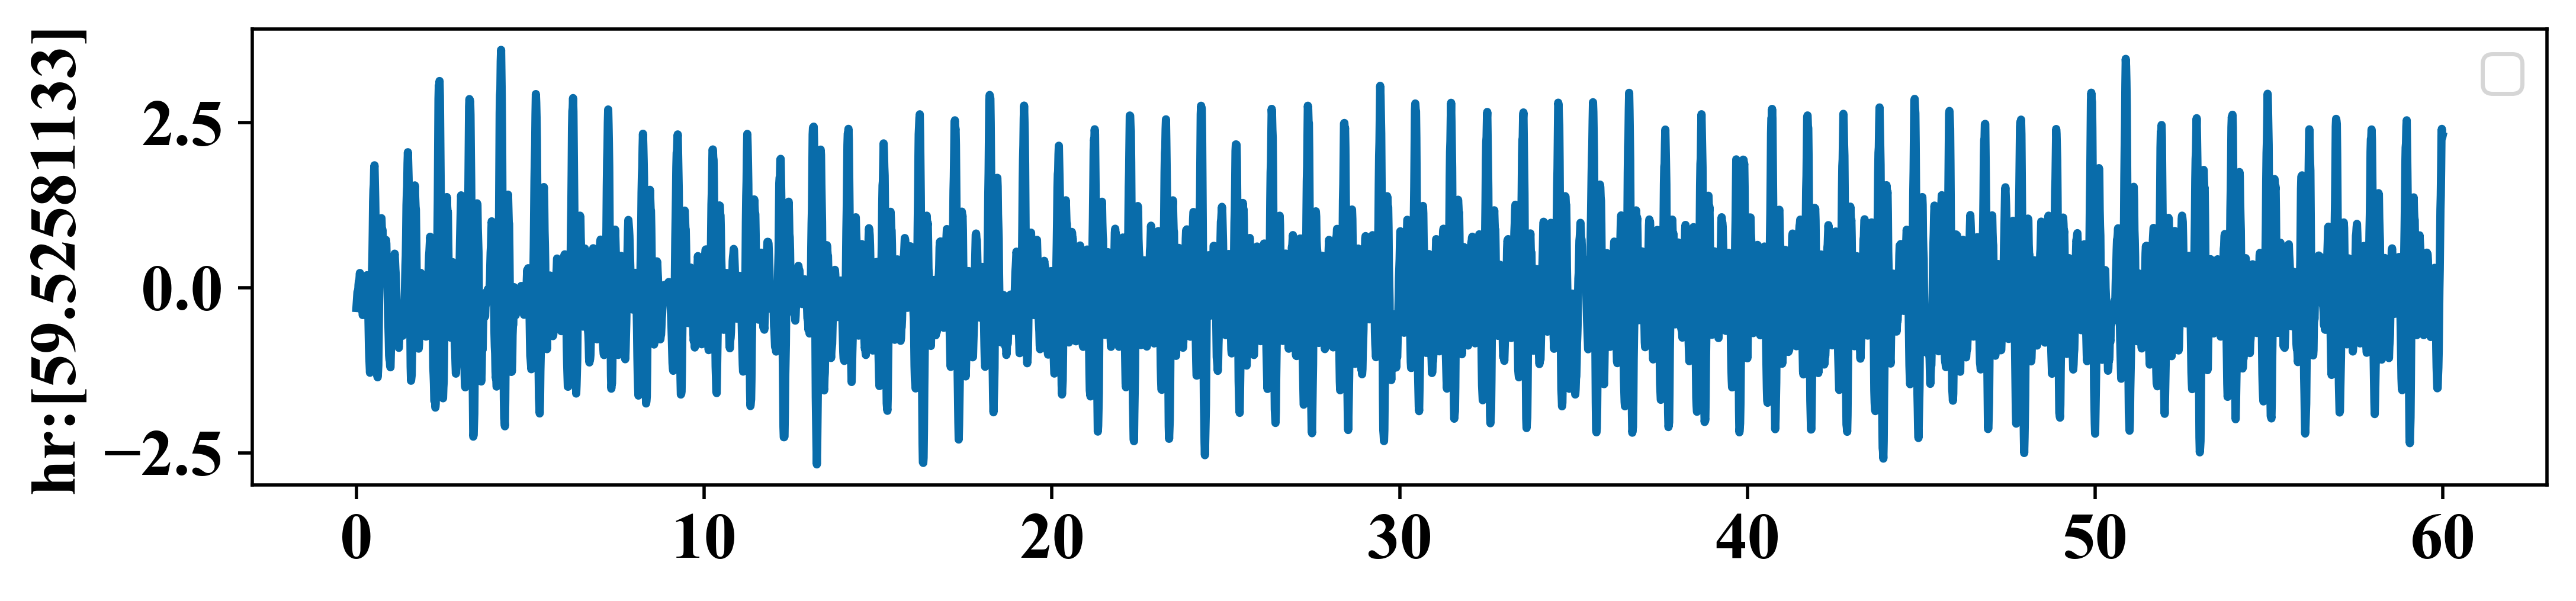

In [10]:
# 查看数据形状并画出图
from utils import *

train_bcg_files=glob.glob(os.path.join(saved_test_dir,"data",category,"*.npy"))
train_b2b_files=glob.glob(os.path.join(saved_test_dir,"label",category,"*.npy"))

print(len(train_bcg_files), len(train_b2b_files))
train_bcg_data=np.load(train_bcg_files[0])
train_b2b_data=np.load(train_b2b_files[0])
print(train_bcg_data.shape, train_b2b_data.shape) # (9, 6000) (9, 1)
# 画图
input=train_bcg_data[0]
plt_plot(
    {
        'x':np.arange(len(input))/100, 'y':input, 'ylabel':f"hr:{train_b2b_data[0]}",'c':'#096caa',   
        # 'hide':{'xticks':False, 'yticks':False, 'b': False},
        # 'rectangle':{'px':3.8,'py':-5, 'w':1.2 ,'h':9, 'lw':2}
    },
)